In [1]:
from datetime import datetime
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from datetime import datetime
import os
from pathlib import Path
import fsspec

import re
pd.set_option('display.max_columns', None)
sys.path.insert(0, os.path.abspath('../..'))
import repo_paths  # noqa: F401
%load_ext autoreload
%autoreload 2
from loading_runs import load_results_from_pickle, compute_rowwise_metrics, plot_metric_vs_lambda

In [2]:
def compute_rowwise_metrics(row, just_f1=True, bin_mask_column='binary_mask'):
    g = np.array(row['g_test'])        # shape (n, p)
    pred = np.array(row[bin_mask_column])
    
    # True Positives, False Positives, False Negatives per row
    TP = np.sum((pred == 1) & (g == 1), axis=1)
    FP = np.sum((pred == 1) & (g == 0), axis=1)
    FN = np.sum((pred == 0) & (g == 1), axis=1)
    
    # Compute metrics per row
    TPR = TP / (TP + FN + 1e-10)
    FDR = FP / (TP + FP + 1e-10)
    F1  = 2 * TP / (2 * TP + FP + FN + 1e-10)
    
    # Take mean across all rows in this experiment
    if just_f1 == True:
        return pd.Series({
                'F1' : np.mean(F1)
            })
    else:
        return pd.Series({
                'TPR': np.mean(TPR),
                'FDR': np.mean(FDR),
                'F1' : np.mean(F1)
            })

## shap grid search

In [14]:
shap = load_results_from_pickle(folder='ICML_experiments/hundred_fea/shap_grid_search',
                                        time_threshold='25_09_03_12_00_00',#"25_07_08_14_00_00",
                                        keep_run_type=None,
                                          is_output=False,
                                  numeric_cols = ['lmbda','accuracy', 'roc_auc', 'pct_sig']
                                        )#'after_hadi_conversation3')# #"%y_%m_%d_%H_%M_%S"

shap['F1'] = shap.apply(compute_rowwise_metrics, axis=1)

shap = shap.query('syn != "Syn7"')

In [15]:
assert (shap.num_syn_features == 100).all()

In [16]:
shap['config_tuple'] = shap['xgb_params'].apply(lambda x: tuple(sorted(x.items())))
shap['config_id'] = shap['config_tuple'].factorize()[0]
cols_shap_num = ['TPR_mean','FDR_mean','f1','roc_auc','pr_auc']
for i in cols_shap_num:
    shap[i] = shap[i].astype(float)

In [17]:
shap.groupby('config_id')[cols_shap_num].mean().sort_values(by='roc_auc',ascending=False).head()

,TPR_mean,FDR_mean,f1,roc_auc,pr_auc
config_id,,,,,
43,64.237667,38.277667,62.665583,0.786762,0.796507
40,64.304639,37.810250,62.982833,0.785116,0.795120
63,65.312055,37.244833,63.714000,0.784391,0.793179
55,65.414889,37.123333,63.828500,0.784248,0.795118
53,65.130333,36.969000,63.818250,0.784163,0.794098


In [18]:
shap.query('config_id==43').iloc[0].xgb_params

{'max_depth': 7,
 'eta': 0.1,
 'colsample_bytree': 1.0,
 'objective': 'binary:logistic',
 'eval_metric': 'logloss',
 'seed': 0,
 'num_boost_round': 100}

these are the best results on seed 0 for xhap with 100 features

# invase_search

In [3]:
temp = load_results_from_pickle(folder='ICML_experiments/hundred_fea/invase_search',
                                        time_threshold='25_09_03_12_00_00',#"25_07_08_14_00_00",
                                        keep_run_type=None,
                                          is_output=False,
                                  numeric_cols = ['lmbda','accuracy', 'TPR_mean','FDR_mean','f1','roc_auc','pr_auc','pct_sig']
                                        )

assert (temp.num_syn_features == 100).all()

temp['F1'] = temp.apply(compute_rowwise_metrics, axis=1)

temp = temp.query('syn != "Syn7"')

In [4]:
temp.groupby(['lmbda'])[['TPR_mean','FDR_mean','f1']].count()

,TPR_mean,FDR_mean,f1
lmbda,,,
0.05,6,6,6
0.10,6,6,6
0.20,6,6,6
0.30,6,6,6
0.40,6,6,6
0.50,6,6,6
0.60,6,6,6
0.80,6,6,6
1.00,6,6,6


In [5]:
a = temp.groupby(['model','lmbda'])[['TPR_mean','FDR_mean','f1','roc_auc','pr_auc','pct_sig']].mean().sort_values(by='roc_auc',ascending=False).reset_index()
a

,model,lmbda,TPR_mean,FDR_mean,f1,roc_auc,pr_auc,pct_sig
0,INVASE,5.00,8.917250,0.845000,13.153143,0.666430,0.672071,0.003896
1,INVASE,3.20,33.455417,0.998333,37.984087,0.665927,0.672083,0.014106
2,INVASE,1.20,67.264667,11.158186,67.199387,0.665272,0.669514,0.034762
3,INVASE,3.00,34.178250,1.244167,39.658413,0.664657,0.671016,0.014458
4,INVASE,10.00,4.710000,0.000000,7.246222,0.664434,0.671151,0.001884
5,INVASE,0.40,96.380944,49.057477,61.137523,0.663847,0.667992,0.144636
6,INVASE,1.40,56.971833,3.409393,59.625527,0.663761,0.668653,0.026368
7,INVASE,0.10,96.638944,93.838956,11.494690,0.663599,0.669998,0.629749
8,INVASE,1.00,68.539222,16.451938,66.917114,0.663023,0.669212,0.038481
9,INVASE,3.40,31.039250,1.178333,35.552063,0.662671,0.670898,0.012957


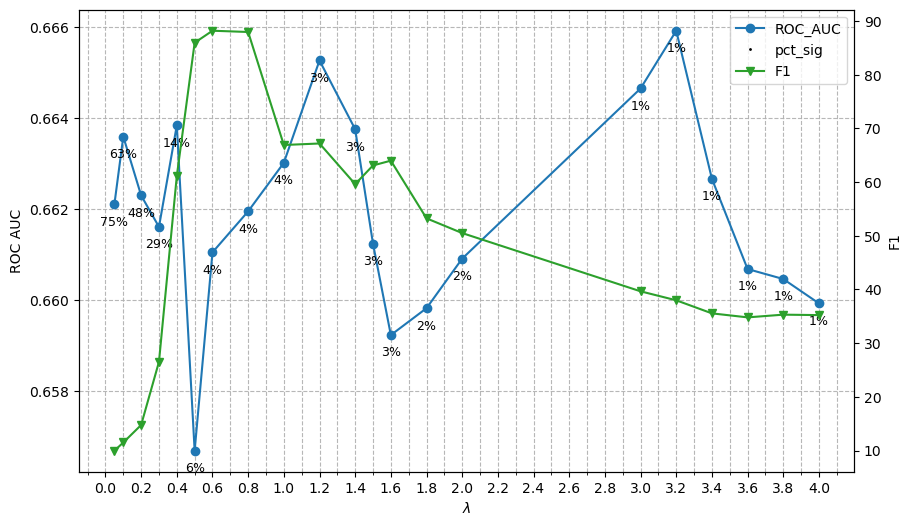

In [10]:
a_sorted = a.sort_values('lmbda')
# Call 1: Sets up the base plot (left y-axis), returns the axis
my_ax = plot_metric_vs_lambda(a_sorted,
                              groupby_cols=None,
                              query='lmbda<5',
                              metric_col='roc_auc',
                              annotate_sig=True,
                             x_ticks=(0,4.2,0.2))

# Call 2: Uses the existing axis, declares itself a twin (right y-axis)
plot_metric_vs_lambda(a_sorted,
                      groupby_cols=None,
                      query='lmbda<5',
                      metric_col='f1',
                      ax=my_ax,
                      annotate_sig=False,
                      is_twin=True)

plt.show()

- so the lmbda we would have chosen is 1.2 but the best F1 (IWFS) is lmbda = 0.6 
- remember that the green is the unknown ground truth - we cannot tune based on it
- I'll run on both and report both

## hide_and_seek_search

In [16]:
temp = load_results_from_pickle(folder='ICML_experiments/hundred_fea/hide_and_seek_search',
                                        time_threshold='25_09_03_12_00_00',#"25_07_08_14_00_00",
                                        keep_run_type=None,
                                          is_output=False,
                                  numeric_cols = ['lmbda','accuracy', 'roc_auc', 'pct_sig','TPR_mean','FDR_mean','f1','pr_auc']
                                        )

assert (temp.num_syn_features == 100).all()

temp['F1'] = temp.apply(compute_rowwise_metrics, axis=1)

temp = temp.query('syn != "Syn7"')

In [17]:
temp.groupby(['lmbda'])[['syn','TPR_mean','FDR_mean','f1']].count()

,syn,TPR_mean,FDR_mean,f1
lmbda,,,,
0.05,6,6,6,6
0.10,6,6,6,6
0.20,6,6,6,6
0.30,6,6,6,6
0.40,6,6,6,6
0.50,6,6,6,6
0.60,6,6,6,6
0.80,6,6,6,6
1.00,6,6,6,6


In [18]:
a = temp.groupby(['model','lmbda'])[['TPR_mean','FDR_mean','f1','roc_auc','pr_auc','pct_sig']].mean().sort_values(by='roc_auc',ascending=False).reset_index()
a

,model,lmbda,TPR_mean,FDR_mean,f1,roc_auc,pr_auc,pct_sig
0,Hide&Seek,2.80,89.838722,17.056387,85.177251,0.787266,0.795435,0.043623
1,Hide&Seek,3.00,88.763305,17.339698,84.568997,0.786122,0.794974,0.043141
2,Hide&Seek,2.60,91.510722,19.338196,84.454501,0.784025,0.791946,0.044811
3,Hide&Seek,2.40,91.940861,19.742381,84.526886,0.783465,0.791466,0.045111
4,Hide&Seek,3.20,84.950305,15.619571,83.598606,0.782419,0.791137,0.040051
5,Hide&Seek,2.20,92.589250,20.214780,84.481623,0.782075,0.789687,0.046136
6,Hide&Seek,3.40,82.700722,15.019492,82.902919,0.776402,0.784712,0.037956
7,Hide&Seek,2.00,91.051333,21.081468,83.350290,0.775596,0.783988,0.045574
8,Hide&Seek,3.60,81.557444,14.298556,82.560986,0.773289,0.781188,0.036995
9,Hide&Seek,1.80,93.488278,22.272934,83.493513,0.771057,0.781030,0.048366


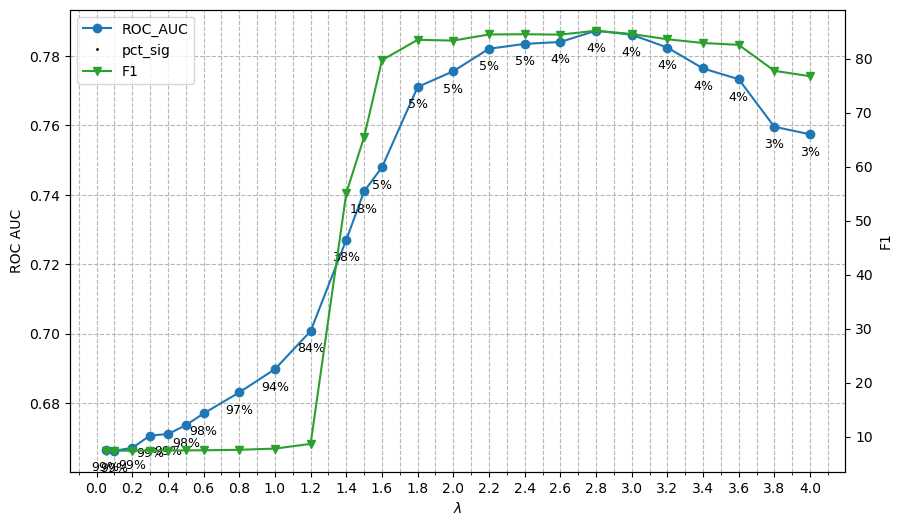

In [19]:
a_sorted = a.sort_values('lmbda')
# Call 1: Sets up the base plot (left y-axis), returns the axis
my_ax = plot_metric_vs_lambda(a_sorted,
                              groupby_cols=None,
                              query='lmbda<5',
                              metric_col='roc_auc',
                              annotate_sig=True,
                             x_ticks=(0,4.2,0.2))

# Call 2: Uses the existing axis, declares itself a twin (right y-axis)
plot_metric_vs_lambda(a_sorted,
                      groupby_cols=None,
                      query='lmbda<5',
                      metric_col='f1',
                      ax=my_ax,
                      annotate_sig=False,
                      is_twin=True)

plt.show()

2.8 is the best auroc, will run test with that. Hide&Seek is easy to tune. Shape consistent across roc_auc, pr_auc

In [21]:
temp.query('lmbda==2.8')[['TPR_mean','FDR_mean','f1','roc_auc','pr_auc','pct_sig']]

,TPR_mean,FDR_mean,f1,roc_auc,pr_auc,pct_sig
96,100.000000,0.000000,100.000000,0.691880,0.694972,0.020000
97,98.507500,0.000000,99.147143,0.880844,0.890351,0.039403
98,94.247500,0.000000,96.686667,0.886713,0.894108,0.037699
99,72.105333,36.845000,65.059997,0.662596,0.671660,0.045049
100,86.416000,30.884500,75.916058,0.765042,0.776833,0.049569
101,87.756000,34.608821,74.253641,0.836520,0.844683,0.070020


## realx search

In [22]:
temp = load_results_from_pickle(folder='ICML_experiments/hundred_fea/realx_search',
                                        time_threshold='25_09_03_12_00_00',#"25_07_08_14_00_00",
                                        keep_run_type=None,
                                          is_output=False,
                                  numeric_cols = ['lmbda','accuracy', 'roc_auc', 'pct_sig','TPR_mean','FDR_mean','f1','pr_auc']
                                        )

assert (temp.num_syn_features == 100).all()

temp['F1'] = temp.apply(compute_rowwise_metrics, axis=1)

temp = temp.query('syn != "Syn7"')

In [23]:
temp.groupby(['lmbda'])[['syn','TPR_mean','FDR_mean','f1']].count()

,syn,TPR_mean,FDR_mean,f1
lmbda,,,,
0.05,6,6,6,6
0.10,6,6,6,6
0.20,6,6,6,6
0.30,6,6,6,6
0.40,6,6,6,6
0.50,6,6,6,6
0.60,6,6,6,6
0.80,6,6,6,6
1.00,6,6,6,6


In [24]:
a = temp.groupby(['model','lmbda'])[['TPR_mean','FDR_mean','f1','roc_auc','pr_auc','pct_sig']].mean().sort_values(by='roc_auc',ascending=False).reset_index()
a

,model,lmbda,TPR_mean,FDR_mean,f1,roc_auc,pr_auc,pct_sig
0,REAL-x,0.20,100.000000,96.128072,7.434476,0.675392,0.684044,0.989579
1,REAL-x,0.10,100.000000,96.169922,7.357154,0.674565,0.682672,0.999865
2,REAL-x,0.05,100.000000,96.170467,7.356147,0.672290,0.679237,1.000000
3,REAL-x,0.30,100.000000,86.594436,21.459737,0.662467,0.671577,0.623389
4,REAL-x,0.40,100.000000,70.012656,43.454636,0.640487,0.650886,0.196423
5,REAL-x,0.50,100.000000,59.279698,55.728350,0.635490,0.645104,0.104152
6,REAL-x,0.60,99.564889,52.349826,61.513082,0.631980,0.641238,0.090440
7,REAL-x,0.80,99.196000,53.625523,61.612091,0.629652,0.640415,0.085419
8,REAL-x,1.20,96.779333,45.766802,67.176520,0.623628,0.635003,0.072979
9,REAL-x,1.00,96.170111,44.013779,68.246383,0.623503,0.633796,0.070685


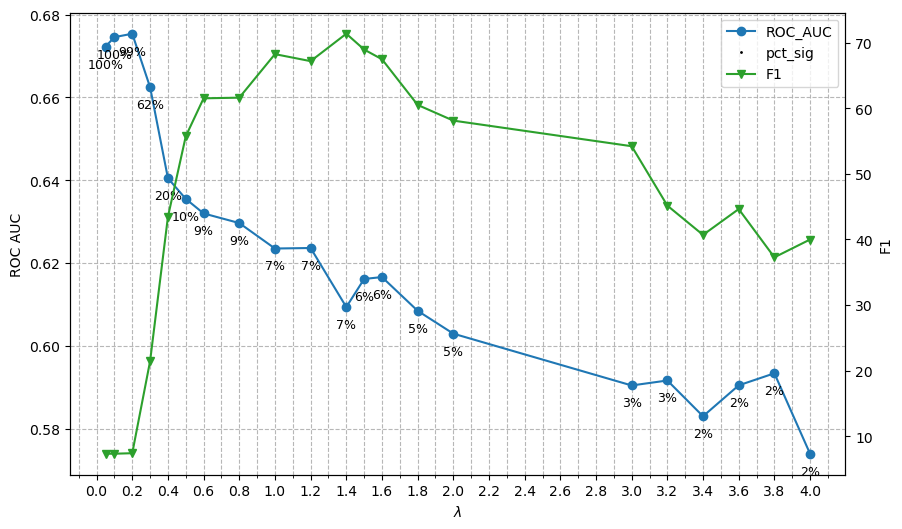

In [25]:
a_sorted = a.sort_values('lmbda')
# Call 1: Sets up the base plot (left y-axis), returns the axis
my_ax = plot_metric_vs_lambda(a_sorted,
                              groupby_cols=None,
                              query='lmbda<5',
                              metric_col='roc_auc',
                              annotate_sig=True,
                             x_ticks=(0,4.2,0.2))

# Call 2: Uses the existing axis, declares itself a twin (right y-axis)
plot_metric_vs_lambda(a_sorted,
                      groupby_cols=None,
                      query='lmbda<5',
                      metric_col='f1',
                      ax=my_ax,
                      annotate_sig=False,
                      is_twin=True)

plt.show()

- best auroc before fall is 1.2, this is what is chosen in tuning. 
- will also report on 1.4 for comparison, as in invase

## comparing

each setting has been run 20 times on different seeds. Now comparing results

In [185]:
def find_switch_accuracy(row):
    switch_accuracy = (row['binary_mask'][:,10] == row['g_test'][:,10]).mean()
    return switch_accuracy

In [186]:
temp = load_results_from_pickle(folder='ICML_experiments/hundred_fea/test',
                                        time_threshold='25_09_03_12_00_00',
                                        keep_run_type=None,
                                          is_output=False,
                                  numeric_cols = ['TPR_mean','FDR_mean','f1','lmbda','accuracy', 'roc_auc', 'pct_sig'],
                                recursive=True,
                                    ignore_folder_prefix='zz_'
                                        )

temp['F1'] = temp.apply(compute_rowwise_metrics, axis=1)
assert (temp.num_syn_features == 100).all()
temp = temp.query('syn != "Syn7"')
temp['syn'] = temp['syn'].str[-1].astype(int)

In [187]:
temp['switch_accuracy'] = temp.apply(lambda row: find_switch_accuracy(row),axis=1)

In [192]:
temp.groupby(['model','syn','lmbda','batchnorm_hs'])[['TPR_mean','FDR_mean','f1']].count()

TPR_mean  FDR_mean  f1
model         syn lmbda batchnorm_hs                        
Hide&Seek     1   2.8   False               20        20  20
                        True                20        20  20
              2   2.8   False               20        20  20
                        True                20        20  20
              3   2.8   False               20        20  20
                        True                20        20  20
              4   2.8   False               20        20  20
                        True                20        20  20
              5   2.8   False               20        20  20
                        True                20        20  20
              6   2.8   False               20        20  20
                        True                20        20  20
Hide&Seek_ens 1   2.8   False               20        20  20
              2   2.8   False               20        20  20
              3   2.8   False               20        20  20
              4   2.8   False               20        20  20
              5   2.8   False               20        20  20
              6   2.8   False               20        20  20
INVASE        1   0.6   False               20        20  20
                  1.2   False               20        20  20
              2   0.6   False               20        20  20
                  1.2   False               20        20  20
              3   0.6   False               20        20  20
                  1.2   False               20        20  20
              4   0.6   False               20        20  20
                  1.2   False               20        20  20
              5   0.6   False               20        20  20
                  1.2   False               20        20  20
              6   0.6   False               20        20  20
                  1.2   False               20        20  20
L2X           1   0.5   False               20        20  20
              2   0.5   False               20        20  20
              3   0.5   False               20        20  20
              4   0.5   False               20        20  20
              5   0.5   False               20        20  20
              6   0.5   False               20        20  20
LIME          1   0.1   False               20        20  20
              2   0.1   False               20        20  20
              3   0.1   False               20        20  20
              4   0.1   False               20        20  20
              5   0.1   False               20        20  20
              6   0.1   False               20        20  20
REAL-x        1   1.2   False               20        20  20
                  1.4   False               20        20  20
              2   1.2   False               20        20  20
                  1.4   False               20        20  20
              3   1.2   False               20        20  20
                  1.4   False               20        20  20
              4   1.2   False               20        20  20
                  1.4   False               20        20  20
              5   1.2   False               20        20  20
                  1.4   False               20        20  20
              6   1.2   False               20        20  20
                  1.4   False               20        20  20
SHAP          1   0.3   False               20        20  20
              2   0.3   False               20        20  20
              3   0.3   False               20        20  20
              4   0.3   False               20        20  20
              5   0.3   False               20        20  20
              6   0.3   False               20        20  20

- INVASE: 0.6 is ideal, 1.2 if tuning without ground truth
- REALx: 1.4 is ideal, 1.2 if tuning without ground truth
- Hide&Seek: three versions: with and without batchnorm, and also the ensemble method

In [193]:
# 1. Define the specific conditions
conditions = [
    (temp['model'] == 'INVASE') & (temp['lmbda'] == 0.6),
    (temp['model'] == 'REAL-x') & (temp['lmbda'] == 1.4),
    (temp['model'] == 'Hide&Seek') & (temp['batchnorm_hs'] == True)
]

# 2. Define the matching new names
choices = [
    'INVASE(I)',
    'REAL-x(I)',
    'Hide&Seek (BN)'
]

# 3. Apply the changes. If no conditions match, keep the original model name.
temp['model'] = np.select(conditions, choices, default=temp['model'])

In [194]:
temp.groupby(['model','syn','lmbda'])[['TPR_mean','FDR_mean','f1']].count()

TPR_mean  FDR_mean  f1
model          syn lmbda                        
Hide&Seek      1   2.8          20        20  20
               2   2.8          20        20  20
               3   2.8          20        20  20
               4   2.8          20        20  20
               5   2.8          20        20  20
               6   2.8          20        20  20
Hide&Seek (BN) 1   2.8          20        20  20
               2   2.8          20        20  20
               3   2.8          20        20  20
               4   2.8          20        20  20
               5   2.8          20        20  20
               6   2.8          20        20  20
Hide&Seek_ens  1   2.8          20        20  20
               2   2.8          20        20  20
               3   2.8          20        20  20
               4   2.8          20        20  20
               5   2.8          20        20  20
               6   2.8          20        20  20
INVASE         1   1.2          20        20  20
               2   1.2          20        20  20
               3   1.2          20        20  20
               4   1.2          20        20  20
               5   1.2          20        20  20
               6   1.2          20        20  20
INVASE(I)      1   0.6          20        20  20
               2   0.6          20        20  20
               3   0.6          20        20  20
               4   0.6          20        20  20
               5   0.6          20        20  20
               6   0.6          20        20  20
L2X            1   0.5          20        20  20
               2   0.5          20        20  20
               3   0.5          20        20  20
               4   0.5          20        20  20
               5   0.5          20        20  20
               6   0.5          20        20  20
LIME           1   0.1          20        20  20
               2   0.1          20        20  20
               3   0.1          20        20  20
               4   0.1          20        20  20
               5   0.1          20        20  20
               6   0.1          20        20  20
REAL-x         1   1.2          20        20  20
               2   1.2          20        20  20
               3   1.2          20        20  20
               4   1.2          20        20  20
               5   1.2          20        20  20
               6   1.2          20        20  20
REAL-x(I)      1   1.4          20        20  20
               2   1.4          20        20  20
               3   1.4          20        20  20
               4   1.4          20        20  20
               5   1.4          20        20  20
               6   1.4          20        20  20
SHAP           1   0.3          20        20  20
               2   0.3          20        20  20
               3   0.3          20        20  20
               4   0.3          20        20  20
               5   0.3          20        20  20
               6   0.3          20        20  20

In [195]:
independent_medians = temp.groupby(['model','syn','lmbda'])[['TPR_mean','FDR_mean','f1','switch_accuracy']].median()
independent_medians.round(0)

TPR_mean  FDR_mean     f1  switch_accuracy
model          syn lmbda                                            
Hide&Seek      1   2.8       100.0      16.0   90.0              1.0
               2   2.8        94.0       0.0   96.0              1.0
               3   2.8        95.0       0.0   97.0              1.0
               4   2.8        70.0      30.0   66.0              1.0
               5   2.8        86.0      31.0   77.0              1.0
               6   2.8        76.0      33.0   70.0              1.0
Hide&Seek (BN) 1   2.8        89.0       0.0   90.0              1.0
               2   2.8        95.0       0.0   96.0              1.0
               3   2.8        89.0       0.0   93.0              1.0
               4   2.8        90.0      31.0   76.0              1.0
               5   2.8        88.0      24.0   80.0              1.0
               6   2.8        91.0      29.0   78.0              1.0
Hide&Seek_ens  1   2.8       100.0       0.0  100.0              1.0
               2   2.8       100.0       0.0  100.0              1.0
               3   2.8        98.0       0.0   99.0              1.0
               4   2.8        79.0      29.0   73.0              1.0
               5   2.8        90.0      28.0   79.0              1.0
               6   2.8        88.0      34.0   75.0              1.0
INVASE         1   1.2         0.0       0.0    0.0              1.0
               2   1.2       100.0       0.0  100.0              1.0
               3   1.2       100.0       0.0  100.0              1.0
               4   1.2        52.0      22.0   53.0              0.0
               5   1.2        55.0      19.0   63.0              1.0
               6   1.2        89.0      18.0   84.0              1.0
INVASE(I)      1   0.6       100.0       0.0  100.0              1.0
               2   0.6       100.0       0.0  100.0              1.0
               3   0.6       100.0       0.0  100.0              1.0
               4   0.6        67.0      40.0   63.0              1.0
               5   0.6        98.0      35.0   75.0              1.0
               6   0.6        99.0      25.0   85.0              1.0
L2X            1   0.5         2.0      98.0    2.0              1.0
               2   0.5        10.0      90.0   10.0              1.0
               3   0.5         4.0      96.0    4.0              1.0
               4   0.5         5.0      96.0    4.0              0.0
               5   0.5         5.0      96.0    4.0              0.0
               6   0.5         5.0      95.0    5.0              0.0
LIME           1   0.1         2.0      98.0    2.0              1.0
               2   0.1       100.0       0.0  100.0              1.0
               3   0.1        78.0      22.0   78.0              1.0
               4   0.1        27.0      75.0   25.0              0.0
               5   0.1        25.0      75.0   25.0              0.0
               6   0.1        40.0      60.0   40.0              0.0
REAL-x         1   1.2       100.0      68.0   48.0              1.0
               2   1.2       100.0      43.0   72.0              1.0
               3   1.2       100.0      13.0   93.0              1.0
               4   1.2        97.0      45.0   68.0              1.0
               5   1.2        92.0      44.0   68.0              1.0
               6   1.2        90.0      46.0   68.0              1.0
REAL-x(I)      1   1.4       100.0      68.0   48.0              1.0
               2   1.4       100.0      43.0   72.0              1.0
               3   1.4       100.0      10.0   94.0              1.0
               4   1.4        95.0      45.0   67.0              1.0
               5   1.4        88.0      42.0   67.0              1.0
               6   1.4        90.0      45.0   68.0              1.0
SHAP           1   0.3        14.0      86.0   14.0              1.0
               2   0.3        92.0       8.0   92.0              1.0
               3   0.3  

- note that REAL-x(I) is not signficantly different from REAL-x. No need to report on it as it is essentially the same. This makes sense as shown by tuning curve (they are similar $\lambda$).
- the batch normalization is generally better than the straight Hide&Seek, but won't include it in the paper to keep things simple. Will focus on the ensembler. Leaving it above for the keen-eyed (it is simply adding BN layers in the network).

In [196]:
import pandas as pd
import numpy as np

def make_latex_table(
    independent_medians: pd.DataFrame,
    model_order,
    syn_range=range(1, 7),
    metrics=("TPR", "FDR"),   # <-- set to ("F1",) or ("TPR","FDR","F1") etc.
    bold_rules=None,         # optional override
):
    df = independent_medians.copy()
    df["syn"] = df["syn"].astype(int)

    # ---- prepare metric columns (rounded ints) ----
    # assumes you have TPR_mean, FDR_mean, and either F1_mean or f1 / F1 already
    if "TPR_mean" in df.columns and "TPR" not in df.columns:
        df["TPR"] = df["TPR_mean"].round().astype(int)
    if "FDR_mean" in df.columns and "FDR" not in df.columns:
        df["FDR"] = df["FDR_mean"].round().astype(int)

    # F1: be flexible with naming
    if "F1" not in df.columns:
        if "f1" in df.columns:
            df["F1"] = df["f1"]
        elif "F1_mean" in df.columns:
            df["F1"] = df["F1_mean"]
        elif "f1_mean" in df.columns:
            df["F1"] = df["f1_mean"]

    if "F1" in df.columns:
        # If your F1 is 0..1 and you want percent-style, change this rounding.
        # Here: if it's <= 1.0, convert to percent; else assume already 0..100.
        if pd.api.types.is_numeric_dtype(df["F1"]):
            if df["F1"].dropna().max() <= 1.0:
                df["F1"] = (100 * df["F1"]).round().astype(int)
            else:
                df["F1"] = df["F1"].round().astype(int)

    metrics = list(metrics)

    # ---- pivots (rows syn, cols model) ----
    pivots = {}
    for met in metrics:
        pivots[met] = (
            df.pivot(index="syn", columns="model", values=met)
              .reindex(columns=model_order)
        )

    # ---- default bolding: TPR max, FDR min, F1 max (per syn) ----
    if bold_rules is None:
        bold_rules = {
            "TPR": ("max",),
            "FDR": ("min",),
            "F1":  ("max",),
        }

    best_per_syn = {}
    for met in metrics:
        rule = bold_rules.get(met, None)
        if rule is None:
            continue
        which = rule[0]
        if which == "max":
            best_per_syn[met] = pivots[met].max(axis=1, skipna=True)
        elif which == "min":
            best_per_syn[met] = pivots[met].min(axis=1, skipna=True)

    def latex_escape_model(name: str) -> str:
        return name.replace("&", r"\&")

    # ---- headers + colspec ----
    k = len(metrics)

    # l|ccc|ccc|... (k columns per model)
    colspec_groups = ["c" * k] * (len(model_order) - 1) + ["c" * k]
    colspec = "l|" + "|".join(colspec_groups)

    header1 = (
        r"\text{Model} "
        + "\n& "
        + "\n& ".join([
            rf"\multicolumn{{{k}}}{{c{'|' if i < len(model_order)-1 else ''}}}{{{latex_escape_model(m)}}}"
            for i, m in enumerate(model_order)
        ])
        + r" \\"
    )

    header2 = (
        r"% \text{Metrics}"
        + "\n& "
        + " & ".join([" & ".join(metrics)] * len(model_order))
        + r" \\"
    )

    # ---- rows ----
    latex_rows = []
    for syn in syn_range:
        row = [f"Syn{syn}"]
        for m in model_order:
            for met in metrics:
                val = pivots[met].loc[syn, m]

                if pd.isna(val):
                    s = "--"
                else:
                    # keep as int if it is int-like; else show with 2 decimals
                    if float(val).is_integer():
                        val_fmt = f"{int(val)}"
                        val_cmp = int(val)
                    else:
                        val_fmt = f"{float(val):.2f}"
                        val_cmp = float(val)

                    # bold if equals best per syn (if defined)
                    if met in best_per_syn:
                        best_val = best_per_syn[met].loc[syn]
                        if not pd.isna(best_val) and val_cmp == best_val:
                            s = rf"\textbf{{{val_fmt}}}"
                        else:
                            s = val_fmt
                    else:
                        s = val_fmt

                row.append(s)

        latex_rows.append(" & ".join(row) + r" \\")

    latex_table = "\n".join([
        rf"\begin{{tabular}}{{{colspec}}}",
        r"\hline",
        header1,
        header2,
        r"\hline",
        *latex_rows,
        r"\hline",
        r"\end{tabular}",
    ])

    return latex_table


# ------------------ USAGE ------------------
model_order = ["Hide&Seek", "Hide&Seek_ens","INVASE", "INVASE(I)","REAL-x", "SHAP", "LIME", "L2X"]

# 1) TPR + FDR (your current)
# print(make_latex_table(independent_medians, model_order, metrics=("TPR","FDR")))

# 2) F1 only
print(make_latex_table(independent_medians.reset_index(), model_order, metrics=("F1",)))

# 3) All three (F1 first)
# print(make_latex_table(independent_medians, model_order, metrics=("F1","TPR","FDR")))


\begin{tabular}{l|c|c|c|c|c|c|c|c}
\hline
\text{Model} 
& \multicolumn{1}{c|}{Hide\&Seek}
& \multicolumn{1}{c|}{Hide\&Seek_ens}
& \multicolumn{1}{c|}{INVASE}
& \multicolumn{1}{c|}{INVASE(I)}
& \multicolumn{1}{c|}{REAL-x}
& \multicolumn{1}{c|}{SHAP}
& \multicolumn{1}{c|}{LIME}
& \multicolumn{1}{c}{L2X} \\
% \text{Metrics}
& F1 & F1 & F1 & F1 & F1 & F1 & F1 & F1 \\
\hline
Syn1 & 90 & \textbf{100} & 0 & \textbf{100} & 48 & 14 & 2 & 2 \\
Syn2 & 96 & \textbf{100} & \textbf{100} & \textbf{100} & 72 & 92 & \textbf{100} & 10 \\
Syn3 & 97 & 99 & \textbf{100} & \textbf{100} & 93 & 88 & 78 & 4 \\
Syn4 & 66 & \textbf{73} & 53 & 63 & 68 & 56 & 25 & 4 \\
Syn5 & 77 & \textbf{79} & 63 & 75 & 68 & 53 & 25 & 4 \\
Syn6 & 70 & 75 & 84 & \textbf{85} & 68 & 72 & 40 & 5 \\
\hline
\end{tabular}


switch accuracy

In [200]:
temp.groupby(['model','syn','lmbda','batchnorm_hs'])[['TPR_mean','FDR_mean','f1','switch_accuracy']].mean()

TPR_mean   FDR_mean          f1  \
model          syn lmbda batchnorm_hs                                      
Hide&Seek      1   2.8   False          99.532250  14.680017   90.626905   
               2   2.8   False          75.207250   1.748725   80.240605   
               3   2.8   False          94.828125   0.000000   97.012262   
               4   2.8   False          56.508233  27.669225   51.760378   
               5   2.8   False          86.860566  29.367319   76.373910   
               6   2.8   False          77.621800  31.160454   71.428937   
Hide&Seek (BN) 1   2.8   True           88.922750   1.114167   89.357033   
               2   2.8   True           95.199000   0.000000   96.413771   
               3   2.8   True           88.591250   0.000000   93.273171   
               4   2.8   True           88.926300  31.687184   74.766700   
               5   2.8   True           87.290700  24.147937   79.432248   
               6   2.8   True           90.029300  28.873004   78.343867   
Hide&Seek_ens  1   2.8   False          99.821750   0.243000   99.728533   
               2   2.8   False          99.855500   0.000000   99.917381   
               3   2.8   False          98.297000   0.000000   99.024667   
               4   2.8   False          73.955666  27.542536   69.955954   
               5   2.8   False          89.277100  27.999112   78.679076   
               6   2.8   False          88.307500  33.278664   75.410375   
INVASE         1   1.2   False          25.000000   0.000000   25.000000   
               2   1.2   False         100.000000   0.000000  100.000000   
               3   1.2   False          99.882625   0.000000   99.932929   
               4   1.2   False          51.845533  24.245592   53.140882   
               5   1.2   False          55.198067  20.203050   62.857033   
               6   1.2   False          89.045100  19.955742   83.125564   
INVASE(I)      1   0.6   False          85.000000   1.613167   84.032100   
               2   0.6   False         100.000000   2.000000   98.888889   
               3   0.6   False          99.955250   0.000000   99.974429   
               4   0.6   False          80.135333  41.165510   66.195632   
               5   0.6   False          95.347700  33.692824   76.292957   
               6   0.6   False          96.900200  22.869789   84.739231   
L2X            1   0.5   False           2.001000  97.999000    2.001000   
               2   0.5   False           9.826750  90.173250    9.826750   
               3   0.5   False           3.805250  96.194750    3.805250   
               4   0.5   False           4.755500  96.329300    4.077500   
               5   0.5   False           5.099300  95.989700    4.418675   
               6   0.5   False           5.110400  94.889600    5.110400   
LIME           1   0.1   False           2.439750  97.560250    2.439750   
               2   0.1   False          99.939000   0.061000   99.939000   
               3   0.1   False          78.131125  21.868875   78.131125   
               4   0.1   False          26.467467  75.386200   25.308925   
               5   0.1   False          25.508567  75.383500   24.951025   
               6   0.1   False          39.526800  60.473200   39.526800   
REAL-x         1   1.2   False          99.590500  67.352788   48.269331   
               2   1.2   False         100.000000  44.054173   71.237466   
               3   1.2   False          98.750000  12.934137   91.892305   
               4   1.2   False          95.182566  45.582133   67.834304   
               5   1.2   False          88.783633  44.203497   66.619642   
               6   1.2   False          91.921000  45.722502   68.157761   
REAL-x(I)      1   1.4   False          96.296750  66.657268   48.717386   
               2   1.4   False         100.000000  42.005132   72.869842   
               3   1.4   False          98.750000  10.364663   93.387258   
             